# IoT Sensor Monitoring with Predictive Maintenance

This notebook covers the full beginner-friendly workflow:

- Import libraries
- Load data
- EDA before cleaning
- Data cleaning
- EDA after cleaning
- Basic plots
- Save cleaned data
- Feature selection
- Train/test split
- Train multiple models
- Select the best model
- Evaluate predictions
- Save and reload the model
- Predict on new data


In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# =========================
# 2. CREATE FOLDERS
# =========================
os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)

print("Folders ready: data, models, plots")

Folders ready: data, models, plots


In [4]:
# =========================
# 3. LOAD DATA
# =========================
# Make sure not_dataset.csv is in the same project folder as this notebook


df = pd.read_csv("IoT_dataset.csv")

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
df.head()

Dataset loaded successfully.
Shape of dataset: (1800, 10)


,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label
0,01/07/24 8:00,M01,0.822,0.645,66.85,13.04,0.196,0.033,0.000,0
1,01/07/24 8:01,M01,1.398,0.834,76.20,15.08,0.345,0.132,0.001,1
2,01/07/24 8:02,M01,0.856,0.590,67.03,12.30,0.187,0.017,0.002,0
3,01/07/24 8:03,M01,0.793,0.544,65.04,11.69,0.196,-0.060,0.003,0
4,01/07/24 8:04,M01,1.279,0.721,78.19,14.84,0.330,-0.115,0.004,1


In [5]:
# Check column names
df.columns.tolist()

['timestamp',
 'machine_id',
 'vibration',
 'acoustic',
 'temperature',
 'current',
 'IMF_1',
 'IMF_2',
 'IMF_3',
 'label']

## EDA Before Cleaning

In [6]:
# Basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    1800 non-null   object 
 1   machine_id   1800 non-null   object 
 2   vibration    1800 non-null   float64
 3   acoustic     1800 non-null   float64
 4   temperature  1800 non-null   float64
 5   current      1800 non-null   float64
 6   IMF_1        1800 non-null   float64
 7   IMF_2        1800 non-null   float64
 8   IMF_3        1800 non-null   float64
 9   label        1800 non-null   int64  
dtypes: float64(7), int64(1), object(2)
memory usage: 140.8+ KB


In [7]:
# Missing values
df.isnull().sum()

timestamp      0
machine_id     0
vibration      0
acoustic       0
temperature    0
current        0
IMF_1          0
IMF_2          0
IMF_3          0
label          0
dtype: int64

In [8]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
# Statistical summary
df.describe(include="all")

,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label
count,1800,1800,1800.000000,1800.000000,1800.000000,1800.00000,1800.000000,1800.000000,1800.000000,1800.000000
unique,600,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,01/07/24 8:00,M01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.843295,0.633898,66.355722,12.32860,0.168738,0.000072,0.000673,0.112222
std,NaN,NaN,0.136690,0.107989,4.448129,1.09451,0.056533,0.073104,0.036034,0.315727
min,NaN,NaN,0.645000,0.430000,58.360000,10.29000,0.073000,-0.180000,-0.050000,0.000000
25%,NaN,NaN,0.769000,0.572000,63.730000,11.70000,0.123000,-0.058000,-0.037000,0.000000
50%,NaN,NaN,0.805000,0.609000,65.355000,12.08000,0.166000,-0.001000,0.003500,0.000000
75%,NaN,NaN,0.851000,0.651250,66.990000,12.48000,0.207000,0.059000,0.037000,0.000000


## Identify the Target Column

In [10]:
possible_targets = [
    "fault",
    "Fault",
    "fault_status",
    "Fault_Status",
    "target",
    "Target",
    "label",
    "Label",
    "failure",
    "Failure",
    "machine_status",
    "Machine_Status",
    "Equipment Failure",
    "Equipment_Status"
]

target_column = None
for col in possible_targets:
    if col in df.columns:
        target_column = col
        break

if target_column is None:
    target_column = df.columns[-1]
    print("Target column not found from common names.")
    print("Using last column as target:", target_column)
else:
    print("Target column identified as:", target_column)

Target column identified as: label


## Data Cleaning

In [11]:
clean_df = df.copy()

# Remove duplicate rows
duplicates_before = clean_df.duplicated().sum()
clean_df = clean_df.drop_duplicates()
duplicates_after = clean_df.duplicated().sum()

print("Duplicate rows before cleaning:", duplicates_before)
print("Duplicate rows after cleaning:", duplicates_after)

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0


In [12]:
# Separate numeric and categorical columns
numeric_cols = clean_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = clean_df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['vibration', 'acoustic', 'temperature', 'current', 'IMF_1', 'IMF_2', 'IMF_3', 'label']

Categorical columns:
['timestamp', 'machine_id']


In [13]:
# Fill missing values
if len(numeric_cols) > 0:
    num_imputer = SimpleImputer(strategy="median")
    clean_df[numeric_cols] = num_imputer.fit_transform(clean_df[numeric_cols])

if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    clean_df[categorical_cols] = cat_imputer.fit_transform(clean_df[categorical_cols])

print("Missing values after cleaning:")
clean_df.isnull().sum()

Missing values after cleaning:


timestamp      0
machine_id     0
vibration      0
acoustic       0
temperature    0
current        0
IMF_1          0
IMF_2          0
IMF_3          0
label          0
dtype: int64

In [14]:
# Save cleaned dataset
cleaned_file_path = "data/cleaned_not_dataset.csv"
clean_df.to_csv(cleaned_file_path, index=False)

print("Cleaned dataset saved to:", cleaned_file_path)

Cleaned dataset saved to: data/cleaned_not_dataset.csv


## EDA After Cleaning

In [15]:
print("Shape after cleaning:", clean_df.shape)
clean_df.head()

Shape after cleaning: (1800, 10)


,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label
0,01/07/24 8:00,M01,0.822,0.645,66.85,13.04,0.196,0.033,0.000,0.0
1,01/07/24 8:01,M01,1.398,0.834,76.20,15.08,0.345,0.132,0.001,1.0
2,01/07/24 8:02,M01,0.856,0.590,67.03,12.30,0.187,0.017,0.002,0.0
3,01/07/24 8:03,M01,0.793,0.544,65.04,11.69,0.196,-0.060,0.003,0.0
4,01/07/24 8:04,M01,1.279,0.721,78.19,14.84,0.330,-0.115,0.004,1.0


In [16]:
clean_df.describe(include="all")

,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label
count,1800,1800,1800.000000,1800.000000,1800.000000,1800.00000,1800.000000,1800.000000,1800.000000,1800.000000
unique,600,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,01/07/24 8:00,M01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.843295,0.633898,66.355722,12.32860,0.168738,0.000072,0.000673,0.112222
std,NaN,NaN,0.136690,0.107989,4.448129,1.09451,0.056533,0.073104,0.036034,0.315727
min,NaN,NaN,0.645000,0.430000,58.360000,10.29000,0.073000,-0.180000,-0.050000,0.000000
25%,NaN,NaN,0.769000,0.572000,63.730000,11.70000,0.123000,-0.058000,-0.037000,0.000000
50%,NaN,NaN,0.805000,0.609000,65.355000,12.08000,0.166000,-0.001000,0.003500,0.000000
75%,NaN,NaN,0.851000,0.651250,66.990000,12.48000,0.207000,0.059000,0.037000,0.000000


In [17]:
clean_df[target_column].value_counts()

label
0.0    1598
1.0     202
Name: count, dtype: int64

## Basic Plots

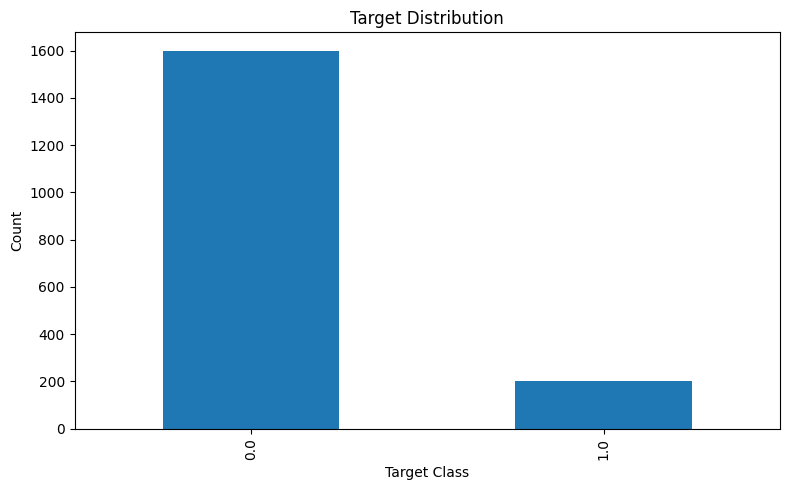

In [18]:
# Plot 1: Target distribution
plt.figure(figsize=(8, 5))
clean_df[target_column].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("plots/target_distribution.png")
plt.show()

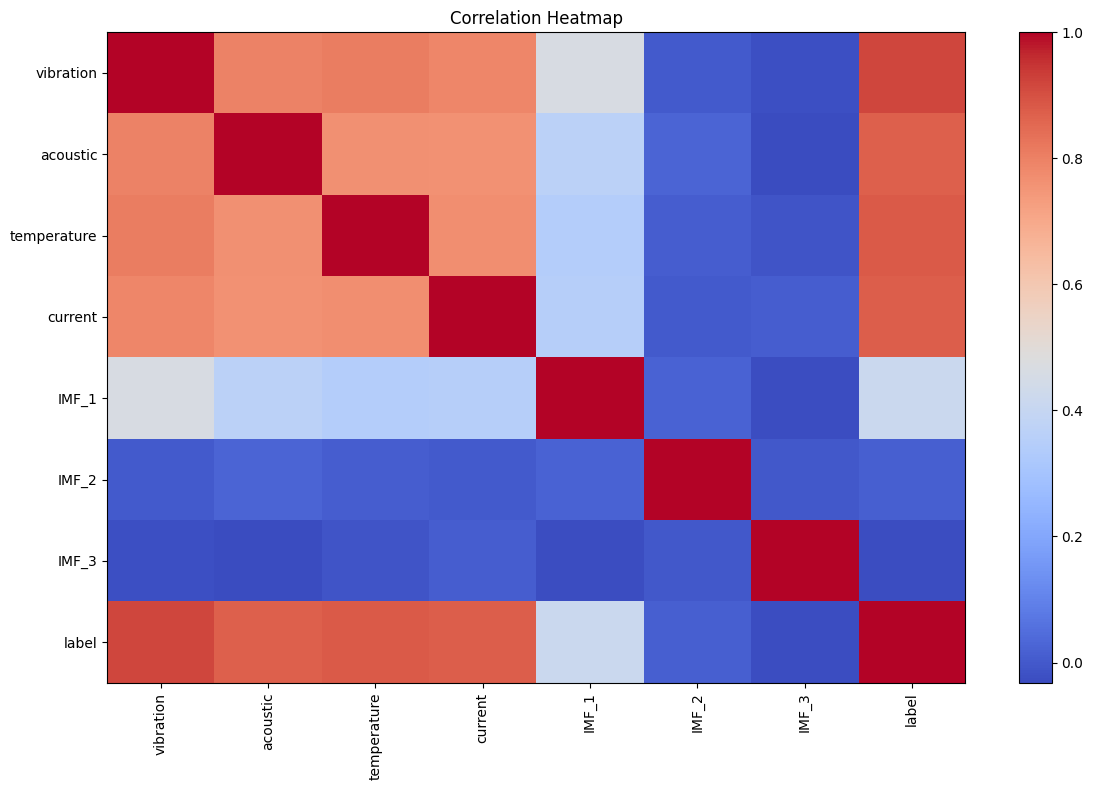

In [20]:
# Plot 3: Correlation heatmap using matplotlib
if len(numeric_cols) > 1:
    corr_matrix = clean_df[numeric_cols].corr()

    plt.figure(figsize=(12, 8))
    plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.savefig("plots/correlation_heatmap.png")
    plt.show()

## Encode Categorical Data

In [21]:
encoded_df = clean_df.copy()
label_encoders = {}

for col in encoded_df.columns:
    if encoded_df[col].dtype == "object":
        le = LabelEncoder()
        encoded_df[col] = le.fit_transform(encoded_df[col].astype(str))
        label_encoders[col] = le

print("Categorical columns encoded successfully.")
encoded_df.head()

Categorical columns encoded successfully.


,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label
0,480,0,0.822,0.645,66.85,13.04,0.196,0.033,0.000,0.0
1,481,0,1.398,0.834,76.20,15.08,0.345,0.132,0.001,1.0
2,482,0,0.856,0.590,67.03,12.30,0.187,0.017,0.002,0.0
3,483,0,0.793,0.544,65.04,11.69,0.196,-0.060,0.003,0.0
4,484,0,1.279,0.721,78.19,14.84,0.330,-0.115,0.004,1.0


## Feature Selection

In [22]:
X = encoded_df.drop(columns=[target_column])
y = encoded_df[target_column]

# Encode target if needed
if y.dtype == "object":
    target_encoder = LabelEncoder()
    y = target_encoder.fit_transform(y.astype(str))
    label_encoders[target_column] = target_encoder

print("Features shape:", X.shape)
print("Target shape:", np.array(y).shape)

Features shape: (1800, 9)
Target shape: (1800,)


In [23]:
# Correlation scores with target
feature_scores = []

for col in X.columns:
    try:
        corr_value = np.corrcoef(X[col], y)[0, 1]
        if np.isnan(corr_value):
            corr_value = 0
        feature_scores.append((col, abs(corr_value)))
    except:
        feature_scores.append((col, 0))

feature_scores = sorted(feature_scores, key=lambda x: x[1], reverse=True)

feature_score_df = pd.DataFrame(feature_scores, columns=["Feature", "Absolute_Correlation"])
feature_score_df

,Feature,Absolute_Correlation
0,vibration,0.918858
1,temperature,0.882900
2,current,0.871425
3,acoustic,0.868588
4,IMF_1,0.418557
5,IMF_3,0.024381
6,timestamp,0.021767
7,IMF_2,0.016049
8,machine_id,0.012934


In [24]:
# Select top features
top_k = min(8, X.shape[1])
top_features = [feature for feature, score in feature_scores[:top_k]]

print("Top selected features:")
print(top_features)

X_selected = X[top_features]
X_selected.head()

Top selected features:
['vibration', 'temperature', 'current', 'acoustic', 'IMF_1', 'IMF_3', 'timestamp', 'IMF_2']


,vibration,temperature,current,acoustic,IMF_1,IMF_3,timestamp,IMF_2
0,0.822,66.85,13.04,0.645,0.196,0.000,480,0.033
1,1.398,76.20,15.08,0.834,0.345,0.001,481,0.132
2,0.856,67.03,12.30,0.590,0.187,0.002,482,0.017
3,0.793,65.04,11.69,0.544,0.196,0.003,483,-0.060
4,1.279,78.19,14.84,0.721,0.330,0.004,484,-0.115


## Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if len(np.unique(y)) > 1 else None
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", np.array(y_train).shape)
print("y_test shape :", np.array(y_test).shape)

X_train shape: (1440, 8)
X_test shape : (360, 8)
y_train shape: (1440,)
y_test shape : (360,)


## Model Training and Selection

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

model_scores = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    model_scores[model_name] = acc
    print(f"{model_name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 1.0000
Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 1.0000


In [27]:
best_model_name = max(model_scores, key=model_scores.get)
best_score = model_scores[best_model_name]
best_model = models[best_model_name]

print("Best model selected:", best_model_name)
print("Best accuracy:", round(best_score, 4))

Best model selected: Logistic Regression
Best accuracy: 1.0


## Reason for Algorithm Selection

- **Random Forest** is often best for predictive maintenance because it handles non-linear sensor patterns, noisy data, and gives feature importance.
- **Decision Tree** is easy to understand and beginner friendly.
- **Logistic Regression** is a good baseline for simple classification.


## Model Evaluation

In [28]:
final_predictions = best_model.predict(X_test)

print("Accuracy Score:")
print(accuracy_score(y_test, final_predictions))

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

Accuracy Score:
1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       320
         1.0       1.00      1.00      1.00        40

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360


Confusion Matrix:
[[320   0]
 [  0  40]]


## Feature Importance

In [31]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": X_selected.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    display(importance_df)

    plt.figure(figsize=(10, 6))
    plt.bar(importance_df["Feature"], importance_df["Importance"])
    plt.xticks(rotation=45)
    plt.title("Feature Importance")
    plt.xlabel("Features")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.savefig("plots/feature_importance.png")
    plt.show()
else:
    print("Feature importance not available for this model.")

Feature importance not available for this model.


## Save the Model

In [32]:
model_path = "models/iot_predictive_maintenance_model.pkl"

joblib.dump({
    "model": best_model,
    "selected_features": top_features,
    "label_encoders": label_encoders,
    "target_column": target_column
}, model_path)

print("Model saved successfully at:", model_path)

Model saved successfully at: models/iot_predictive_maintenance_model.pkl


## Reload the Model

In [33]:
saved_objects = joblib.load(model_path)

loaded_model = saved_objects["model"]
loaded_features = saved_objects["selected_features"]
loaded_label_encoders = saved_objects["label_encoders"]
loaded_target_column = saved_objects["target_column"]

print("Model reloaded successfully.")
print("Selected features used by model:", loaded_features)

Model reloaded successfully.
Selected features used by model: ['vibration', 'temperature', 'current', 'acoustic', 'IMF_1', 'IMF_3', 'timestamp', 'IMF_2']


## Prediction with New Data

In [34]:
# Use one sample row from X_test as new data
new_data = X_test.iloc[[0]].copy()

print("New input data:")
display(new_data)

new_prediction = loaded_model.predict(new_data)[0]
print("Raw predicted output:", new_prediction)

if loaded_target_column in loaded_label_encoders:
    decoded_prediction = loaded_label_encoders[loaded_target_column].inverse_transform([new_prediction])[0]
    print("Decoded predicted class:", decoded_prediction)
else:
    print("Predicted class:", new_prediction)

New input data:


,vibration,temperature,current,acoustic,IMF_1,IMF_3,timestamp,IMF_2
508,0.78,67.63,12.18,0.607,0.113,-0.034,388,0.013


Raw predicted output: 0.0
Predicted class: 0.0


## Multiple Sample Predictions

In [35]:
sample_new_data = X_test.iloc[:5].copy()
sample_predictions = loaded_model.predict(sample_new_data)

output_rows = []
for i, pred in enumerate(sample_predictions):
    if loaded_target_column in loaded_label_encoders:
        pred_label = loaded_label_encoders[loaded_target_column].inverse_transform([pred])[0]
    else:
        pred_label = pred
    output_rows.append({"Row_Number": i + 1, "Predicted_Target": pred_label})

pd.DataFrame(output_rows)

,Row_Number,Predicted_Target
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0


## Save Sample Predictions

In [36]:
prediction_output = sample_new_data.copy()
prediction_output["Predicted_Target"] = sample_predictions

if loaded_target_column in loaded_label_encoders:
    prediction_output["Predicted_Target"] = loaded_label_encoders[loaded_target_column].inverse_transform(
        prediction_output["Predicted_Target"].astype(int)
    )

prediction_output.to_csv("data/sample_predictions.csv", index=False)
print("Sample predictions saved to: data/sample_predictions.csv")

Sample predictions saved to: data/sample_predictions.csv


## Final Output Files

After running the notebook, you will have:

- `data/cleaned_not_dataset.csv`
- `data/sample_predictions.csv`
- `models/iot_predictive_maintenance_model.pkl`
- plot images inside the `plots/` folder
